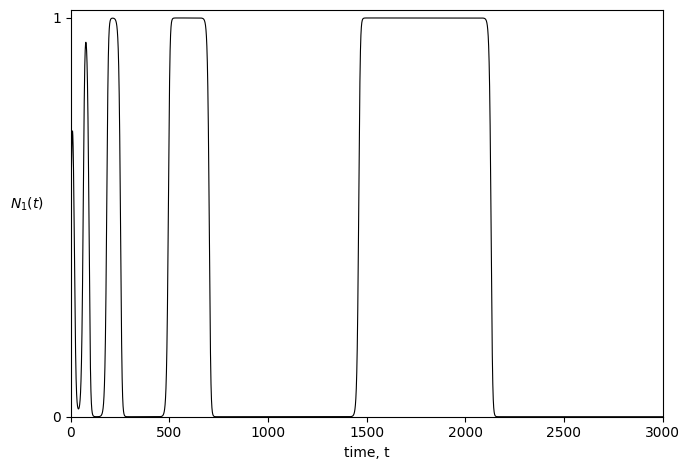

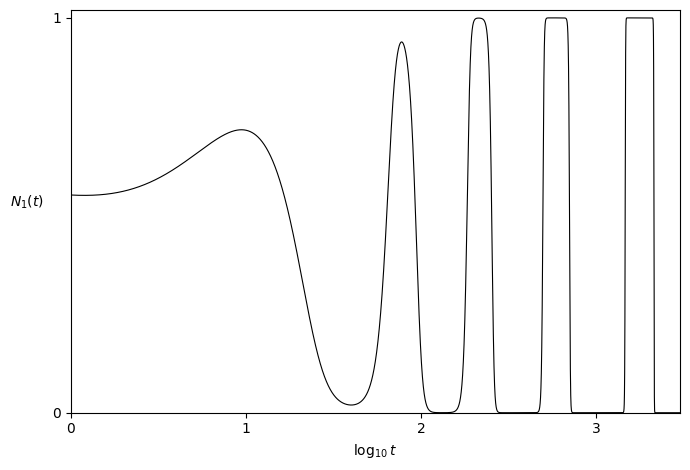

Saved Figure 4 to: /Users/edward/dev/figure4.png
Saved Figure 5 to: /Users/edward/dev/figure5.png


In [ ]:
# ###########################################################################
# Author: Edward E. Daisey
# Course: Modeling & Simulation of Complex Systems
# Title: May-Leonard System - Reproduction of Figures 4 and 5
# Date: 3rd of March, 2026
###############################################################################

################################### Overview ##################################
# Description:
#   This script simulates the May-Leonard three-species competition model
#   and reproduces Figures 4 and 5 from May and Leonard (1975).
#
# Model:
#   dN1/dt = N1 * [1 - (N1 + alpha*N2 + beta*N3)]
#   dN2/dt = N2 * [1 - (beta*N1 + N2 + alpha*N3)]
#   dN3/dt = N3 * [1 - (alpha*N1 + beta*N2 + N3)]
#
# Parameters:
#   alpha = 0.8
#   beta  = 1.3
#
# Initial Condition:
#   N1(0) = 0.6
#   N2(0) = 0.6
#   N3(0) = 0.1
#
# Time Interval:
#   t in [10^(-1), 10^4]
#
# Reproducibility:
#   (1) Install the required Python packages.
#   (2) Run this script.
#   (3) The script will save the two requested figures to the notebook's
#       current working directory and display them inline.
#
# References:
#   May, R. M. and Leonard, W. J. 1975. Nonlinear aspects of competition between
#   three species. SIAM Journal on Applied Mathematics 29, 2 (1975), 243-253.
#   http://www.jstor.org/stable/2100478
# ###########################################################################


# ############################ Imports ######################################
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from pathlib import Path
# ###########################################################################


# ############################ Constants ####################################
alpha = 0.8
beta = 1.3

initialState = [0.6, 0.6, 0.1]

timeStart = 1e-1
timeEnd = 1e4

relativeTolerance = 1e-8
absoluteTolerance = 1e-10
maximumStep = 1.0

outputDirectory = Path.cwd()
figure4Filename = "figure4.png"
figure5Filename = "figure5.png"
# ###########################################################################


# ############################ Function 1 ###################################
# Name:
#   MayLeonard
#
# Purpose:
#   Returns the time derivatives for the May-Leonard three-species system.
#
# Input:
#   t     : Current time.
#   state : Current state vector [n1, n2, n3].
#
# Output:
#   A list containing the derivatives [dN1, dN2, dN3].
def MayLeonard(t, state):
    n1, n2, n3 = state

    dN1 = n1 * (1 - (n1 + alpha * n2 + beta * n3))
    dN2 = n2 * (1 - (beta * n1 + n2 + alpha * n3))
    dN3 = n3 * (1 - (alpha * n1 + beta * n2 + n3))

    return [dN1, dN2, dN3]
# ###########################################################################


# ############################ Function 2 ###################################
# Name:
#   SolveSystem
#
# Purpose:
#   Numerically solves the May-Leonard system on t in [10^(-1), 10^4].
#
# Input:
#   None.
#
# Output:
#   A SciPy solution object with dense output enabled.
def SolveSystem():
    solution = solve_ivp(
        MayLeonard,
        (timeStart, timeEnd),
        initialState,
        dense_output=True,
        rtol=relativeTolerance,
        atol=absoluteTolerance,
        max_step=maximumStep
    )

    return solution
# ###########################################################################


# ############################ Function 3 ###################################
# Name:
#   PlotFigure4
#
# Purpose:
#   Reproduces Figure 4 by plotting N1(t) versus t on a linear time axis.
#
# Input:
#   solution : The numerical solution returned by SolveSystem().
#
# Output:
#   Saves the linear-time plot to the notebook working directory and displays it.
def PlotFigure4(solution):
    timeLinear = np.linspace(0.0, 3000.0, 20000)
    evaluationTimes = np.maximum(timeLinear, timeStart)
    n1Linear = solution.sol(evaluationTimes)[0]

    figurePath = outputDirectory / figure4Filename

    plt.figure(figsize=(7, 4.8))
    plt.plot(timeLinear, n1Linear, "k-", linewidth=0.8)
    plt.xlim(0, 3000)
    plt.ylim(0, 1.02)
    plt.yticks([0, 1])
    plt.grid(False)
    plt.xlabel("time, t")
    plt.ylabel(r"$N_1(t)$", rotation=0, labelpad=18)
    plt.tight_layout()
    plt.savefig(figurePath, dpi=300, bbox_inches="tight")
    plt.show()

    return figurePath
# ###########################################################################


# ############################ Function 4 ###################################
# Name:
#   PlotFigure5
#
# Purpose:
#   Reproduces Figure 5 by plotting N1(t) versus log10(t), following the paper.
#
# Input:
#   solution : The numerical solution returned by SolveSystem().
#
# Output:
#   Saves the logarithmic-time plot to the notebook working directory and displays it.
def PlotFigure5(solution):
    timeLogarithmic = np.logspace(0, np.log10(3000.0), 20000)
    n1Logarithmic = solution.sol(timeLogarithmic)[0]
    log10Time = np.log10(timeLogarithmic)

    figurePath = outputDirectory / figure5Filename

    plt.figure(figsize=(7, 4.8))
    plt.plot(log10Time, n1Logarithmic, "k-", linewidth=0.8)
    plt.xlim(0, np.log10(3000.0))
    plt.ylim(0, 1.02)
    plt.yticks([0, 1])
    plt.xticks([0, 1, 2, 3])
    plt.grid(False)
    plt.xlabel(r"$\log_{10} t$")
    plt.ylabel(r"$N_1(t)$", rotation=0, labelpad=18)
    plt.tight_layout()
    plt.savefig(figurePath, dpi=300, bbox_inches="tight")
    plt.show()

    return figurePath
# ###########################################################################


# ############################ Function 5 ###################################
# Name:
#   Main
#
# Purpose:
#   Solves the May-Leonard system and saves Figures 4 and 5.
#
# Input:
#   None.
#
# Output:
#   Produces the two requested figures in the notebook working directory.
def Main():
    solution = SolveSystem()
    figure4Path = PlotFigure4(solution)
    figure5Path = PlotFigure5(solution)

    print(f"Saved Figure 4 to: {figure4Path}")
    print(f"Saved Figure 5 to: {figure5Path}")
# ###########################################################################


# ############################# Execution ###################################
Main()
# ###########################################################################